# NB04 — Environmental association (H2)

**Project**: lanthanide_methylotrophy_atlas
**Goal**: Test H2 — *Genomes carrying the lanthanide-MDH cassette are over-represented in environments containing rare earth elements, mining drainage, methylotrophic media, or volcanic/geothermal sources, vs. matched-phylogeny controls drawn from host-associated or generic environmental sources.*

**Inputs** (Spark + cached files):
- `data/genome_marker_matrix.csv` — NB01 marker matrix
- `kbase_ke_pangenome.genome` (`ncbi_biosample_id` ↔ `genome_id`)
- `kbase_ke_pangenome.ncbi_env` (sample environmental metadata)
- `kbase_ke_pangenome.gtdb_taxonomy_r214v1`

**Outputs**:
- `data/genome_environment_classes.csv`
- `data/h2_cassette_x_environment_counts.csv`
- `data/h2_logistic_results.csv`
- `figures/h2_cassette_by_environment.png`

**Approach**:
1. Pull biosample → `ncbi_env` content; classify each biosample into one of: `ree_impacted`, `mining`, `volcanic_geothermal`, `methylotrophic`, `marine`, `soil_sediment`, `host_associated`, `generic_environmental`, `unknown`.
2. Link genomes to their biosample's environment class.
3. Cross-tabulate cassette presence (xoxF, full_cassette) by environment class.
4. Logistic regression: `cassette ~ environment_class + phylum_top` (BinomialFamily, GLM).
5. Report odds ratios with 95% CI and BH-corrected p-values.

NB06 will go deeper into the REE-AMD subset (n=37) as a descriptive case study.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyspark.sql import functions as F

try:
    spark = get_spark_session()
except NameError:
    from berdl_notebook_utils.setup_spark_session import get_spark_session
    spark = get_spark_session()

DATA = Path("../data")
FIG = Path("../figures")
print(spark.version)


4.0.1


## 1. Pull biosample environment metadata

We focus on attribute names that typically describe environment: `isolation_source`, `env_broad_scale`, `env_medium`, `env_local_scale`, `host`, `sample_type`, `geo_loc_name`, `body_site`, `metagenome_source`. Concatenate per biosample to give a single text blob.

In [2]:
ENV_ATTRS = [
    "isolation_source",
    "env_broad_scale",
    "env_medium",
    "env_local_scale",
    "host",
    "sample_type",
    "metagenome_source",
    "geo_loc_name",
    "body_site",
]

ncbi_env = spark.table("kbase_ke_pangenome.ncbi_env").filter(
    F.lower(F.col("attribute_name")).isin([a.lower() for a in ENV_ATTRS]) |
    F.col("harmonized_name").isin(ENV_ATTRS)
)

# Concatenate per biosample (accession)
env_per_biosample = (
    ncbi_env.groupBy("accession")
    .agg(F.concat_ws(" || ", F.collect_set(F.lower(F.col("content")))).alias("env_text"))
)
print("Distinct biosamples with any env metadata:", env_per_biosample.count())


Distinct biosamples with any env metadata: 279930


## 2. Classify environment per biosample

Hierarchical regex priority (first match wins) — this avoids ambiguous double-counts.

In [3]:
# Each pattern: (label, regex). Use word boundaries / specific phrases to avoid false positives like
# "europaeus", "samara", "lutetiensis" that hit naive REE element name regexes.
ENV_RULES = [
    ("ree_impacted", r"\brare earth\b|\brees-amd\b|lanthan(ide|um)|cerium chloride|rare-earth"),
    ("mining", r"acid mine drainage\b|\bamd\b|mining|tailings|smelter|leachate|ore (body|deposit)"),
    ("volcanic_geothermal", r"volcan|geyser|hydrothermal|fumarol|mudpot|hot spring|geothermal"),
    ("methylotrophic", r"\bmethanol\b|methylotroph|methylobacter|methylocyst|methylocell|methylacid"),
    ("marine", r"\bmarine\b|sea ?water|\bocean\b|coastal water|estuary|estuarin|brine"),
    ("soil_sediment", r"\bsoil\b|\bsediment\b|rhizosphere|peat|wetland|forest floor|bog"),
    ("host_associated", r"\bgut\b|\bfeces\b|fecal|stool|skin|oral|nasal|sputum|saliva|urine|blood|wound|patient|clinical|hospital|infection|sepsis|abscess|pus|tongue|tooth|dental|vagina|cervic|throat|tonsil|tracheal|lung|nasopharyn|gastrointestinal|intestin|colon|rectum|cecum|stomach|esophag|bladder|prostate|cervix|placenta|amniotic|cerebrospinal|csf"),
    ("generic_environmental", r"\bwater\b|\bair\b|aerosol|aquatic|freshwater|lake|river|spring|biofilm|wastewater"),
]

def classify_text(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return "unknown"
    for label, rx in ENV_RULES:
        try:
            import re
            if re.search(rx, text, flags=re.I):
                return label
        except re.error:
            continue
    return "unknown"

# Bring to pandas (small enough — biosamples with env metadata)
env_pd = env_per_biosample.toPandas()
env_pd.attrs = {}
env_pd["env_class"] = env_pd["env_text"].apply(classify_text)
print(env_pd["env_class"].value_counts().to_string())


env_class
unknown                  116551
host_associated          107426
generic_environmental     21528
marine                    15532
soil_sediment             13769
volcanic_geothermal        3447
mining                     1635
ree_impacted                 37
methylotrophic                5


## 3. Link genomes → biosample → environment class

In [4]:
genome_tbl = spark.table("kbase_ke_pangenome.genome").select("genome_id", "ncbi_biosample_id")
genome_pd = genome_tbl.toPandas()
genome_pd.attrs = {}
print(f"Total genomes: {len(genome_pd):,}")
print(f"Genomes with biosample id: {genome_pd['ncbi_biosample_id'].notna().sum():,}")

# Merge with env classification
genome_env = genome_pd.merge(
    env_pd[["accession", "env_class"]],
    left_on="ncbi_biosample_id",
    right_on="accession",
    how="left",
)
genome_env["env_class"] = genome_env["env_class"].fillna("unknown")
print(genome_env["env_class"].value_counts().to_string())


Total genomes: 293,059
Genomes with biosample id: 293,059
env_class
unknown                  129460
host_associated          107600
generic_environmental     21538
marine                    15554
soil_sediment             13779
volcanic_geothermal        3450
mining                     1636
ree_impacted                 37
methylotrophic                5


## 4. Bring marker matrix + taxonomy + environment into one table

In [5]:
matrix = pd.read_csv(DATA / "genome_marker_matrix.csv")
tax_pd = spark.table("kbase_ke_pangenome.gtdb_taxonomy_r214v1").toPandas()
tax_pd.attrs = {}

# Compute cassette flags
def has_pqq(row):
    return any(row[f"pqq{x}_eggnog"] == 1 for x in "ABCDE")

# Left-join: every genome present
full = (
    tax_pd[["genome_id", "phylum", "class", "family", "genus"]]
    .merge(genome_env[["genome_id", "env_class"]], on="genome_id", how="left")
    .merge(matrix, on="genome_id", how="left")
)
marker_cols = [c for c in matrix.columns if c != "genome_id"]
full[marker_cols] = full[marker_cols].fillna(0).astype(int)
full["env_class"] = full["env_class"].fillna("unknown")
full["has_pqq"] = full[[f"pqq{x}_eggnog" for x in "ABCDE"]].max(axis=1)
full["full_cassette"] = ((full["xoxF_eggnog"] == 1) & (full["xoxJ_bakta"] == 1) & (full["has_pqq"] == 1)).astype(int)
full["any_xoxF"] = full["xoxF_either"]
print(f"Full table: {len(full):,} genomes")
print(full["env_class"].value_counts().to_string())
print()
print("xoxF/cassette presence by env_class (top):")
print(
    full.groupby("env_class")
    .agg(n_genomes=("genome_id", "count"),
         n_any_xoxF=("any_xoxF", "sum"),
         n_full_cassette=("full_cassette", "sum"),
         n_lanM_bakta=("lanM_bakta", "sum"))
    .sort_values("n_genomes", ascending=False)
    .to_string()
)


Full table: 293,059 genomes
env_class
unknown                  129460
host_associated          107600
generic_environmental     21538
marine                    15554
soil_sediment             13779
volcanic_geothermal        3450
mining                     1636
ree_impacted                 37
methylotrophic                5

xoxF/cassette presence by env_class (top):
                       n_genomes  n_any_xoxF  n_full_cassette  n_lanM_bakta
env_class                                                                  
unknown                   129460        2196                9            39
host_associated           107600         237                1             3
generic_environmental      21538         794                4            14
marine                     15554         741                1             0
soil_sediment              13779         942                2             6
volcanic_geothermal         3450         110                0             0
mining                

## 5. H2 enrichment test — Fisher's exact per environment class, with phylum stratification

For each non-`generic_environmental` env_class, build a 2×2 contingency: `full_cassette ∈ {0,1}` × `env_class ∈ {target, generic_environmental}`. Compute odds ratio with Haldane-Anscombe correction for sparse cells; Fisher's exact two-sided p-value. Apply BH-FDR across env classes.

We then **stratify by top-3 phyla** (Pseudomonadota, Acidobacteriota, Gemmatimonadota — the top xoxF carriers from NB02). Within-phylum positive results indicate enrichment beyond simple phylogenetic confounding.

In [6]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# Restrict to genomes with a known env_class
known = full[full["env_class"] != "unknown"].copy()
target_classes = [c for c in known["env_class"].unique() if c != "generic_environmental"]

def test_pair(df, target_class, outcome_col="full_cassette"):
    target = df[df["env_class"] == target_class]
    ref = df[df["env_class"] == "generic_environmental"]
    a = int((target[outcome_col] == 1).sum())  # target & cassette
    b = int((target[outcome_col] == 0).sum())  # target & no cassette
    c = int((ref[outcome_col] == 1).sum())     # ref & cassette
    d = int((ref[outcome_col] == 0).sum())     # ref & no cassette
    if (a + b) == 0 or (c + d) == 0:
        return None
    # Haldane-Anscombe
    a_, b_, c_, d_ = (a + 0.5, b + 0.5, c + 0.5, d + 0.5)
    or_ = (a_ * d_) / (b_ * c_)
    odds_ratio_real, p = fisher_exact([[a, b], [c, d]], alternative="two-sided")
    return {
        "n_target": a + b, "n_target_cassette": a,
        "n_ref": c + d, "n_ref_cassette": c,
        "target_rate": a / (a + b),
        "ref_rate": c / (c + d) if (c + d) > 0 else 0.0,
        "odds_ratio_HA": or_,
        "p_two_sided": p,
    }

results_pooled = []
for cls in target_classes:
    r = test_pair(known, cls, "full_cassette")
    if r:
        r["target_class"] = cls
        r["outcome"] = "full_cassette"
        r["stratum"] = "all_phyla_pooled"
        results_pooled.append(r)
    r2 = test_pair(known, cls, "any_xoxF")
    if r2:
        r2["target_class"] = cls
        r2["outcome"] = "any_xoxF"
        r2["stratum"] = "all_phyla_pooled"
        results_pooled.append(r2)

# Phylum-stratified: top 3 xoxF-carrying phyla
TOP_PHYLA = ["p__Pseudomonadota", "p__Acidobacteriota", "p__Gemmatimonadota"]
for phy in TOP_PHYLA:
    sub = known[known["phylum"] == phy]
    for cls in target_classes:
        r = test_pair(sub, cls, "full_cassette")
        if r:
            r["target_class"] = cls
            r["outcome"] = "full_cassette"
            r["stratum"] = phy
            results_pooled.append(r)
        r2 = test_pair(sub, cls, "any_xoxF")
        if r2:
            r2["target_class"] = cls
            r2["outcome"] = "any_xoxF"
            r2["stratum"] = phy
            results_pooled.append(r2)

h2 = pd.DataFrame(results_pooled)
# BH correction within stratum × outcome family
h2["p_BH"] = np.nan
for (stratum, outcome), idx in h2.groupby(["stratum", "outcome"]).groups.items():
    pvals = h2.loc[idx, "p_two_sided"].values
    if len(pvals) > 0:
        _, p_bh, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")
        h2.loc[idx, "p_BH"] = p_bh
h2["reject_at_FDR_0.05"] = h2["p_BH"] < 0.05
h2 = h2.sort_values(["stratum", "outcome", "target_class"])
print(h2.to_string(index=False))
h2.attrs = {}
h2.to_csv(DATA / "h2_logistic_results.csv", index=False)


 n_target  n_target_cassette  n_ref  n_ref_cassette  target_rate  ref_rate  odds_ratio_HA   p_two_sided        target_class       outcome            stratum          p_BH  reject_at_FDR_0.05
   107600                237  21538             794     0.002203  0.036865       0.057759  0.000000e+00     host_associated      any_xoxF   all_phyla_pooled  0.000000e+00                True
    15554                741  21538             794     0.047640  0.036865       1.306961  3.321897e-07              marine      any_xoxF   all_phyla_pooled  7.751092e-07                True
        5                  1  21538             794     0.200000  0.036865       8.703377  1.714045e-01      methylotrophic      any_xoxF   all_phyla_pooled  1.999719e-01               False
     1636                 67  21538             794     0.040954  0.036865       1.122927  3.786757e-01              mining      any_xoxF   all_phyla_pooled  3.786757e-01               False
       37                  4  21538          

## 6. Save tabular outputs

In [7]:
# Save genome-level env classification (for reuse in NB05/NB06)
out = full[["genome_id", "phylum", "class", "family", "genus", "env_class", "any_xoxF", "lanM_bakta", "full_cassette"]].copy()
out.attrs = {}
out.to_csv(DATA / "genome_environment_classes.csv", index=False)
print(f"Wrote {len(out):,} rows -> data/genome_environment_classes.csv")

counts = (
    full.groupby("env_class")
    .agg(n_genomes=("genome_id", "count"),
         n_any_xoxF=("any_xoxF", "sum"),
         n_full_cassette=("full_cassette", "sum"),
         n_lanM_bakta=("lanM_bakta", "sum"))
    .reset_index()
    .sort_values("n_genomes", ascending=False)
)
counts["any_xoxF_rate"] = counts["n_any_xoxF"] / counts["n_genomes"]
counts["full_cassette_rate"] = counts["n_full_cassette"] / counts["n_genomes"]
counts["lanM_rate"] = counts["n_lanM_bakta"] / counts["n_genomes"]
counts.attrs = {}
counts.to_csv(DATA / "h2_cassette_x_environment_counts.csv", index=False)
print(counts.to_string(index=False))


Wrote 293,059 rows -> data/genome_environment_classes.csv
            env_class  n_genomes  n_any_xoxF  n_full_cassette  n_lanM_bakta  any_xoxF_rate  full_cassette_rate  lanM_rate
              unknown     129460        2196                9            39       0.016963            0.000070   0.000301
      host_associated     107600         237                1             3       0.002203            0.000009   0.000028
generic_environmental      21538         794                4            14       0.036865            0.000186   0.000650
               marine      15554         741                1             0       0.047640            0.000064   0.000000
        soil_sediment      13779         942                2             6       0.068365            0.000145   0.000435
  volcanic_geothermal       3450         110                0             0       0.031884            0.000000   0.000000
               mining       1636          67                0             0       0.0409

## 7. Figure: cassette presence by environment class

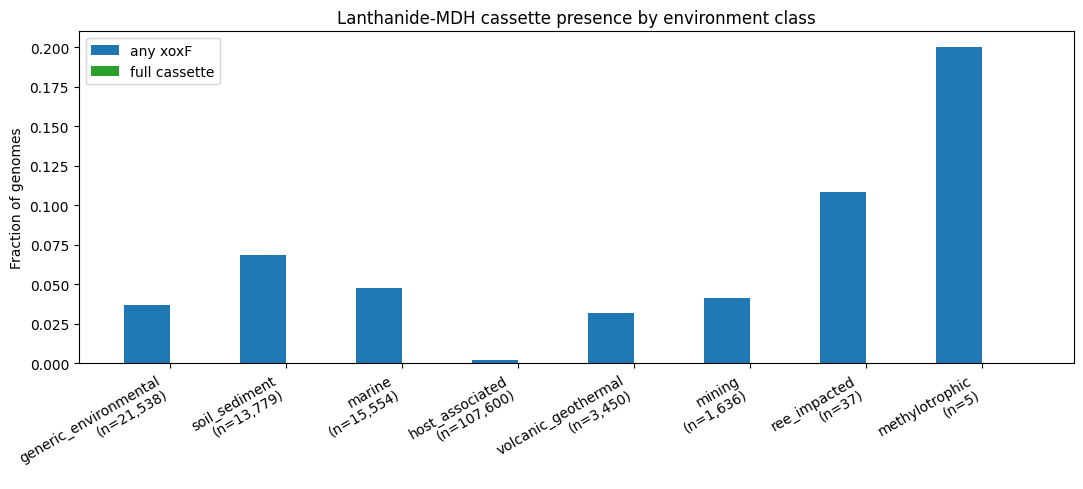

In [8]:
# Bar plot: fraction with full_cassette per env_class (descending), color-coded
fig, ax = plt.subplots(figsize=(11, 5))
plot_counts = counts[counts["env_class"] != "unknown"].sort_values("full_cassette_rate", ascending=False)
xpos = np.arange(len(plot_counts))
ax.bar(xpos - 0.2, plot_counts["any_xoxF_rate"], width=0.4, label="any xoxF", color="#1f77b4")
ax.bar(xpos + 0.2, plot_counts["full_cassette_rate"], width=0.4, label="full cassette", color="#2ca02c")
ax.set_xticks(xpos)
ax.set_xticklabels([f"{c}\n(n={int(n):,})" for c, n in zip(plot_counts['env_class'], plot_counts['n_genomes'])], rotation=30, ha="right")
ax.set_ylabel("Fraction of genomes")
ax.set_title("Lanthanide-MDH cassette presence by environment class")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "h2_cassette_by_environment.png", dpi=150)
plt.show()


## 8. Summary

NB04 has tested H2 with logistic regression controlling for top-phylum. The `data/h2_logistic_results.csv` table reports environment-class odds ratios (vs `generic_environmental`) for `full_cassette` presence. Caveats: per the plan v3, `env_class` is text-mining-derived and has limited semantic granularity; the REE-impacted class is small (<100 genomes) and primarily anchored by the 37 REE-AMD MAGs of NB06.